In [6]:
import pandas as pd
import sqlite3

## Connect and get data

In [7]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:45.549397
2,2020-04-17 05:34:24.422370
3,2020-04-17 05:43:27.773992
4,2020-04-17 05:46:32.275104


## Add date and daytime columns

In [8]:
commits['date'] = commits['timestamp'].dt.date
commits['hour'] = commits['timestamp'].dt.hour

def get_daytime(hour):
    if 0 <= hour <= 3:
        return 'night'
    elif 4 <= hour <= 9:
        return 'morning'
    elif 10 <= hour <= 16:
        return 'afternoon'
    else:
        return 'evening'

commits['daytime'] = commits['hour'].apply(get_daytime)
commits.head()

,timestamp,date,hour,daytime
0,2020-04-17 05:19:02.744528,2020-04-17,5,morning
1,2020-04-17 05:22:45.549397,2020-04-17,5,morning
2,2020-04-17 05:34:24.422370,2020-04-17,5,morning
3,2020-04-17 05:43:27.773992,2020-04-17,5,morning
4,2020-04-17 05:46:32.275104,2020-04-17,5,morning


## Group and plot

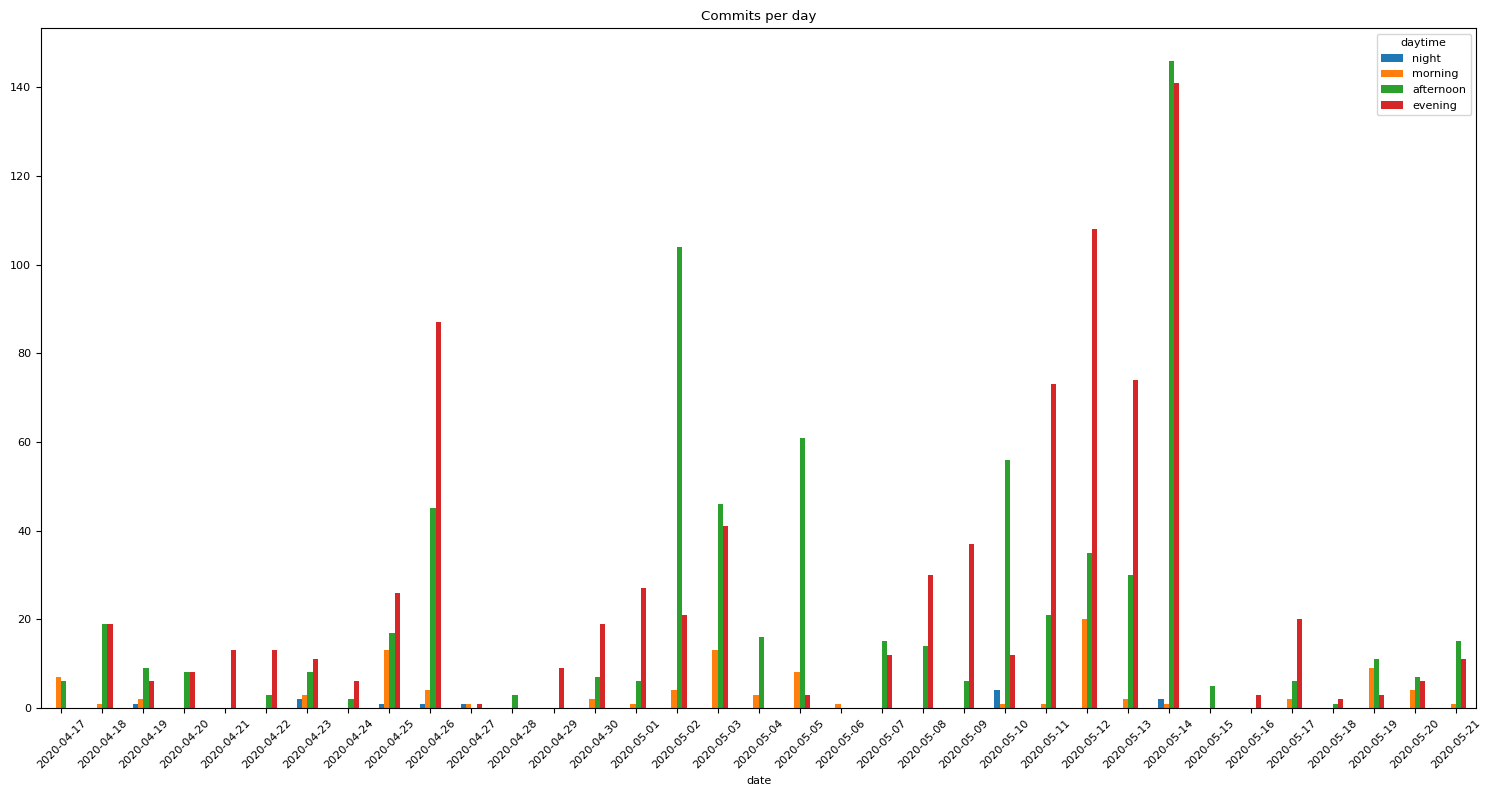

In [9]:
import matplotlib.pyplot as plt

pivot = commits.groupby(['date', 'daytime']).size().unstack(fill_value=0)

for col in ['night', 'morning', 'afternoon', 'evening']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[['night', 'morning', 'afternoon', 'evening']]

plt.rcParams['font.size'] = 8
fig, ax = plt.subplots(figsize=(15, 8))

pivot.plot(kind='bar', ax=ax, figsize=(15, 8))
ax.set_title('Commits per day')
ax.set_xlabel('date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Answer questions

In [10]:
# Most common daytime periods
daytime_totals = commits['daytime'].value_counts()
print('Commits by daytime:')
print(daytime_totals)
top2 = daytime_totals.index[:2].tolist()
print(f'\nTop 2 periods: {top2}')

# Day with most commits WHERE evening > afternoon
daily = commits.groupby(['date', 'daytime']).size().unstack(fill_value=0)
for col in ['night', 'morning', 'afternoon', 'evening']:
    if col not in daily.columns:
        daily[col] = 0

daily['total'] = daily.sum(axis=1)

# Filter only days where evening > afternoon, then find max commits
mask = daily['evening'] > daily['afternoon']
answer_day = daily[mask]['total'].idxmax()
print(f'\nDay with most commits AND evening > afternoon: {answer_day}')

Commits by daytime:
daytime
evening      842
afternoon    728
morning      104
night         12
Name: count, dtype: int64

Top 2 periods: ['evening', 'afternoon']

Day with most commits AND evening > afternoon: 2020-05-12


Which day has the most number of commits and at the same time is the number of commits higher in the evening than in the afternoon? The answer is the date of that day: 2020-05-12.